In [1]:
%matplotlib inline
# Use autoreload so that updating hmm_class.py is immediately reflected in future cell executions in the notebook.
# For details on the autoreload extension, see
# https://ipython.org/ipython-doc/3/config/extensions/autoreload.html
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image
from sklearn.metrics import ConfusionMatrixDisplay
from hmm_class import HMM
from gaussian import Gaussian

# Hidden Markov Models (HMMs)

Up to this point all the data we have worked with has been treated as i.i.d. - i.e. all the different observations were viewed as independent from each other - even when this clearly is not the case, such as with the signature data where each coordinate depends on past coordinates. 

One of the most fundamental tasks of machine learning is to model dependencies between variables. HMMs have been designed to do just this. These days we know that HMMs are just a particularly simple example of a more general class of models, namely Probabilistic Graphical Models. 

HMMs model dynamic processes, or processes that can be thought of as being dynamic. In practice this means that we observe a dynamic process that provides us with observations (or samples) at successive time instances. Signatures are good examples: At fixed intervals, the tablet registers the $x$ and $y$ coordinates of the pen (among other things). Plotted in sequence, we display the signature. 

For the HMM model, the idea is that at each time instant generating an observation, the system is in one of a finite set of $k$ (emitting) states. This means that we are dealing with discrete states. Although we do not investigate it here, it is also possible to assume continuous states, a situation modeled by the Kalman filter. In either case, the state sequence, as one proceeds from one time instance to the next, is hidden (unknown), hence the *Hidden* in Hidden Markov models.

Each emitting state is associated with a probability density function (pdf). We will use the Gaussian distribution for simplicity; a more general choice would be Gaussian Mixture Models (GMMs). The model then specifies that the observation generated by an emitting state is obtained by sampling from the state's pdf.  Thus the data we observe in practice is viewed as being generated by sampling the pdf's of the emitting states, while the underlying state changes over time.

It is convenient to work with additional, non-emitting states, as well.  For this course (and in your code), the initial and final states, numbered -1 and  $k$, are non-emitting. 

The parameters associated with an HMM, and which typically need to be learned from training data, are

* The transition probabilities $A_{ij}$, where $A_{ij}$ is the probability that the system will next enter state $j$, given that it is currently in state $i$. This is what makes it a (first-order) *Markov* model, since the next state is only determined by the previous state, and not earlier ones. In the context of PGMs, it is conceptually not hard to generalize this to higher-order models, but we will only concern ourselves with first order models. Also note that it is possible to remain in the same state, i.e. $A_{ii}$ is not necessarily zero. Note that in principle there is no limitation on how to proceed between states. The implementation you will develop in this assignment allows only a left-to-right model, however. That means that from state $i$ one can only proceed to state $j$ if $j\geq i$. Finally note that the $A_{ij}$ are probabilities and therefore normalized so that $\sum_j A_{ij} = 1$.  An additional row and column are added to the bottom and right of $A$ in the code, to model transitions from the initial non-emitting state and into the final non-emitting state respectively.
* As mentioned above, each emitting state is associated with a pdf, in our case a Gaussian. The pdf's also need to be estimated during the training stage. This phase is sensitive to strange situations where not enough data is associated with a specific hidden state, leading to degenerate Gaussians and similar problems.  **The code may thus discard unused emitting states during the training process**.
* HMMs are *generative* models, i.e. it is possible to draw samples from a trained HMM. For example, for a signature verification system a model might be developed from the available signatures of a signatory.  Then it is possible to generate sample "signatures" which resemble this training data from the perspective of the model.

### Software

`scikit-learn` does not have an HMM implementation; instead in this assignment you will develop an HMM library from a skeleton provided to you.  To keep things manageable, we will only consider left-to-right topologies with Gaussian emission densities.  (You may also be interested in investigating or experimenting with the HMMlearn python library.)

The skeleton code provided in `hmm_class.py` you are provided with has various functions for you to complete - these are indicated by the `pass` keyword.  By executing the class (with `python3 hmm_class.py` on the command line), various doctests are executed to indicate whether your code functions as expected.  These doctests are essentially ipython sessions showing code with expected corresponding output.

*Some guidelines on implementation order*:

0. Carefully read the docstrings and review the doctests in the included skeleton file to develop an understanding of the structure of the class.
1. You are required to implement the whole or part of 7 functions.
2. Four of them can be tested by creating an HMM with specified transition matrix and emission densities using the load function: sample, \_forward, \_score, and \_viterbi.
3. The most crucial is \_viterbi, since this is needed by \_calcstates.
4. \_updatecovs is used along with \_calcstates to implement \_em.

Note that running this after implementation is quite a big computation, so can take quite a while.  Our implementation takes around 15 seconds on a Dell Latitute E6520.


### A simple example

As a simple example to see what is happening, let us consider a simple example, based on the example in the code comments. Here we provide the system with 2 sequences of 1-dimensional observations for training, the first with 11 observations, and the second with 7.

By observation of the signals, it should not be hard to see that the data is roughly clustered around 3 values, namely 1.0, 0.1 and 3.5. We therefore specify 3 states.  Fitting the model yields transition probabilities between the states, as well as the parameters (means and covariances) of the Gaussian densities associated with each state.

We print the trained HMM parameters from the solution code below - note that this corresponds to a portion of the doctest specifed for the HMM class. **Verify that the output makes sense to you.  Ensure you understand what the last row and column in the transition table are for.**

In [3]:
# SAMPLE CODE: EXECUTION WILL INITIALLY FAIL

# Define signals
signal1 = np.array([[ 1. ,  1.1,  0.9, 1.0, 0.0,  0.2,  0.1,  0.3,  3.4,  3.6,  3.5]])
signal2 = np.array([[0.8, 1.2, 0.4, 0.2, 0.15, 2.8, 3.6]])

# Collect training data together
toy_data = np.hstack([signal1, signal2])
toy_lengths = [11, 7]

# Create and fit HMM model to data
toy_hmm = HMM()
toy_hmm.fit(toy_data, toy_lengths, 3)

toy_means = [d.get_mean() for d in toy_hmm.dists]
toy_covs = [d.get_cov() for d in toy_hmm.dists]
print ('Transition probabilities: ')
print (toy_hmm.trans)
print ('Means: ')
print (toy_means)
print ('Covariances: ')
print (toy_covs)

Transition probabilities: 
[[0.66666667 0.33333333 0.         0.        ]
 [0.         0.71428571 0.28571429 0.        ]
 [0.         0.         0.6        0.4       ]
 [1.         0.         0.         0.        ]]
Means: 
[array([1.]), array([0.19285714]), array([3.38])]
Covariances: 
[array([[0.01666667]]), array([[0.01459184]]), array([[0.0896]])]


The above toy model represents a fully working model. At this point the toy model will not work until you have implemented various methods. Let us build your intuition,suppose you are given the following parameters:

In [4]:
means = [1.0,0.19285714, 3.38]     
covs = [0.01666667, 0.01459184, 0.0896]

***Now given the above parameters,use the gaussian class to initialize Gaussian objects with the given means and variances.
Once you have initialized the Gaussian objects, use the load function in the skeleton HMM class provided to initialize an HMM model with the name toy_hmm.***

In [5]:
trans= np.array([[0.66666667, 0.33333333, 0.0,0.0],[0.0,0.71428571,0.28571429,0.0],[0.0,0.0,0.6,0.4],[1.0,0.0,0.0 , 0.0]])
dists = [Gaussian(np.array([mean]), np.array([[cov]])) for mean, cov in zip(means, covs)]
toy_hmm = HMM()
toy_hmm.load(trans, dists)

### Sampling from an HMM

Since an HMM is a generative model, one is able to sample from the model to generate data from the distribution represented by the model.  This process interleaves sampling state transitions and observations from the corresponding state's emission density until a transition to the final non-emitting state is reached.

**Complete the implementation of the sample function in the skeleton code provided in this assignment, and use it to sample a signal from the toy model. Print out sampled signals with their associated state sequences and states for each emission. The results vary because of random selection of the state sequences by the sampling function.**

In [6]:
samples, states = toy_hmm.sample()
print(samples)
# Expected output: The results will vary 
#Samples
#[[0.83719479]
# [0.21245065]
# [0.12488386]
# [0.18980902]
# [0.22644558]
# [0.1983044 ]
# [0.22731078]
# [3.57053262]]
#Emission states
#[0 1 1 1 1 1 1 2]

[[1.27539484 1.03833647 0.8124177  0.94377952 0.19333649 3.13871897
  3.67384972 3.14918311]]


### Calculating (log-)likelihoods
 We are interested in finding joint log-likelihood for some sequence, or the (marginal) log-likelihood of the observation.  **Thus you must implement two functions in the HMM class which are documented in the code, namely _score and _forward.** 

Below is some sample output of the toy example to verify your code against:

***Complete the skeleton code for the _score function and verify your outputs for the two signals given below.***

In [7]:
signal3 = np.array([[ 0.9515792,   0.9832767,   1.04633007,  1.01464327,  0.98207072,  1.01116689,
  0.31622856,  0.20819263,  3.57707616]])
signal4 = np.array([[ 1,   0.6,   0.5 , 3.57707616]]) 
print(toy_hmm.score(signal3, [0, 0, 0, 0, 0, 1, 1, 1, 2]))
print(toy_hmm.score(signal4, [0,1,1,2]))


# Correct output for the 2 print lines above:
#-19.900843242451643
#-8.928550038779658

-19.900838967520045
-8.928548508991248


***Identify explicitly all possible state sequences for signal4 above, and calculate the score for each. Identify the sequence with the maximum score and its associated score.  Convert each score (i.e. log-likelihood) back to a likelihood, add them up for all the state sequences, and then take the logarithm again to get an overall score for the observation. Your results here should give you a sanity check on the forward algorithm and Viterbi algorithm when you implement them below.***

In [8]:
def enumerate_state_sequences(trans, n_obs):
    sequences = []

    def extend(prefix):
        if len(prefix) == n_obs:
            if trans[prefix[-1], -1] > 0:
                sequences.append(prefix.copy())
            return

        current = prefix[-1]
        for nxt in np.where(trans[current, :-1] > 0)[0]:
            extend(prefix + [int(nxt)])

    for start in np.where(trans[-1, :-1] > 0)[0]:
        extend([int(start)])

    return sequences

seqs4 = enumerate_state_sequences(trans, signal4.shape[1])
scores4 = [toy_hmm.score(signal4, seq) for seq in seqs4]

for seq, score in zip(seqs4, scores4):
    print(seq, score)

best_idx = int(np.argmax(scores4))
print('Best sequence:', seqs4[best_idx])
print('Best score:', scores4[best_idx])

marginal_ll = np.logaddexp.reduce(scores4)
print('Marginal log-likelihood from explicit summation:', marginal_ll)
print('Forward log-likelihood:', toy_hmm.forward(signal4))

[0, 0, 1, 2] -8.183945894952732
[0, 1, 1, 2] -8.928548508991248
[0, 1, 2, 2] -53.063545782364024
Best sequence: [0, 0, 1, 2]
Best score: -8.183945894952732
Marginal log-likelihood from explicit summation: -7.795340116574731
Forward log-likelihood: -7.795340116574732


# Forward algorithm
***Given signal 3 and 4,complete the skeleton code for forward algorithm and compare your output using the two signals.*** You can similarly check your forward algorithm by explicitly scoring all the possible sequences for a short signal (such as the 4-observation toy example earlier in this notebook) and ensuring the sum of the corresponding likelihoods corresponds to the (marginal) likelihood returned by the forward algorithm.

**Note that the functions return log-likelihoods, and you need to add the associated likelihoods! When doing this (including when implementing the forward algorithm), you often need to add likelihoods together with vastly differing magnitudes.  This can lead to inaccuracy, overflow, underflow, and general numerical computation nastiness.  To avoid much of this unpleasantness, you will likely want to make use of numpy's logaddexp function.**

In [9]:
# Forward algorithm outputs 
print(toy_hmm.forward(signal3))
print(toy_hmm.forward(signal4))
# Expected output:
#2.905341680210209
#-7.795340116574732

2.905341680210209
-7.795340116574732


### Training

Usually we'll be given several training sequences produced by the same entity, e.g. several examples of the signatures of a single signatory will be available. The next step is to choose the number of emitting states $k$. This usually requires experimentation using a validation set. Assume for now that it is known.

The training again proceeds using an EM algorithm called **Viterbi re-estimation**. The basic idea is simple:
* First estimate or guess the transition probabilities as well as the pdf's associated with each state.
* Use the present estimate of the HMM parameters to fit an observation sequence to the model. This is done by **the Viterbi algorithm that finds the optimal state sequence for the observation sequence**. Keep a record of the obervations that are assigned to each state. Also keep a count of the number of state transitions. Do this for all the training sequences. After all the training sequences have been processed, each state should have a number of observations assigned to it. (If there is an empty state, it should be deleted). The observations associated with a state are used to estimate the pdf of that state. Since counts are also calculated for the various state transitions, they only need to be normalized in order to find new state transition probabilities.
* With a new estimate of the HMM available, the process is repeated until convergence.

(Note that unlike the EM algorithm for fitting a GMM, which used responsibilities to allocate data points to multiple clusters, **observations are assigned fully to one of the emitting states**.  A similar partial (or soft) allocation strategy exists that can be used for HMM training, called the Baum-Welch algorithm.)

# Viterbi algorithm
Given an observation sequence, the Viterbi algorithm finds the optimal state transition sequence that explains the observations. This really lies at the heart of the HMM. We explained above how crucial the Viterbi algorithm is during training. It lies also at the heart of inference.
***Complete the skeleton code for the Viterbi algorithm and compare your output using the two signals given below.*** One sanity check for the log-likelihood from your Viterbi algorithm is ensuring it returns the same log-likelihood as the score function on the sequence identified by the Viterbi algorithm.

In [10]:
signal5 = np.array([[ 0.9515792,   0.9832767,   1.04633007,  1.01464327,  1.98207072,  1.01116689,
  0.31622856,  0.20819263,  2.57707616]])
seq5, ll5 = toy_hmm.viterbi(signal5)
print(seq5)
print(ll5)

signal6 = np.array([[ 1,   0.6,   1.9773 , 2.653997]]) 
seq6, ll6 = toy_hmm.viterbi(signal6)
print(seq6)
print(ll6)
# Expected output:
#[0 0 0 0 0 0 1 1 2]
#-29.39974846423692
#[0 1 2 2]
#-20.482121728698644

[0 0 0 0 0 0 1 1 2]
-29.399743355225212
[0 1 2 2]
-20.48212074424268


Note that the code above also gives the most likely sequence of states for the given model, not necessarily the true underlying state sequence.  **It is instructive to work through the steps of last example with a calculator or in the Python interpreter, to ensure you do not make common errors which would lead to returning the erroneous sequence [0 1 1 2].**

**Complete the implementation of the \_calcstates, \_updatecovs, and \_em in the skeleton code provided in this assignment, and use it to train the toy\_hmm and compare your results from those at the beginning. Please note that the signals are also required when using the fit() function.**

# Preparing the data.

In this assignment, we will apply HMMs to the signature data that we have used in earlier assignments - again using only the $x$- and $y$-components. We read only 3 of the 15 signatures of a signatory in with `read_signatures` and use them for training. Note how the training signatures are first normalized, and then presented to the system. Note that later you will test a signature classification system using the other 12 signatures for each signatory.

In [11]:
# Some utility functions:

def read_signatures(file):
    '''
    Read all the signatures in a given directory.
    
    Parameters:
    -----------
    file: string
        The name of the directory.
        
    Return:
    -------
    sign: (n,) list
        A list with all the signatures in the directory.
    
    Example
    -------
    >>>from utils import read_signatures
    >>>sign = read_signatures('./data/signatures/sign1/*.txt')       
    >>>print len(sign)
       15
    >>>print sign[0].shape
       (5, 306)
    '''
    import glob
    list_of_files = glob.glob(file) 
    sign = []
    for file_name in list_of_files:
        sign.append(np.loadtxt(file_name,  comments = '%').T)
    return sign

def sign_norm(sign):
    '''   
    Normalize a signature with respect to position, scale and rotation. 
    The aspect ratio is kept intact. Note that only the x,y coordinates are
    used.
    
    Parameters
    -----------
    sign: (2,n) ndarray
        The signature, consisting of n samples of x,y coordinates.
    
    Return
    ------
    
    rot_sign: (2,n) ndarray
        The normalized signature.
    '''
    #sign = sign
    d,n = sign.shape
    sign = sign - np.mean(sign,axis=1)[:,np.newaxis]
    #sign = (sign - mean)
    u, s, vh = np.linalg.svd(sign,full_matrices=False)
    # Try and establish the correct sign of the singular vectors.
    if u[0,0]<0. :
        vh[0,:] = -vh[0,:]
    if u[1,1]<0. :
        vh[1,:] = -vh[1,:]
    sign_norm = np.sqrt(n)*np.diag(s).dot(vh)/s[0]
    return sign_norm

(2, 1720)
[587, 603, 530]


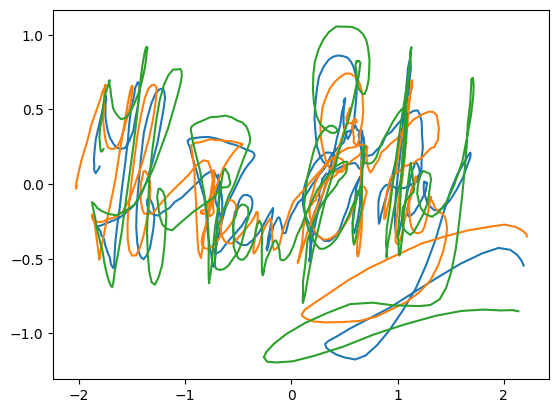

In [12]:
sign = read_signatures('../resources/data/signatures/sign2/*.txt')
n_signs = len(sign)-12
data = sign_norm(sign[0][:2, :])
length = [sign[0].shape[1]]
plt.figure("Signatures: signatory 2")
plt.plot(data[0,:],data[1,:])
for i in range(n_signs-1):
    signi = sign_norm(sign[i+1][:2, :])
    data = np.hstack((data,signi))
    length.append(sign[i+1].shape[1])
    plt.plot(signi[0,:],signi[1,:])
print (data.shape)
print (length)

***Use the approach above to read in training signatures for each signatory, and train an HMM for each signatory using 5 states and diagonal covariance matrices (we will use most of these models later).  Use your EM and Viterbi algorithm implemetation you have completed above.***

In [13]:
def get_signer_data(signer_num, num_features=2, num_test=12):
    sign = read_signatures('../resources/data/signatures/sign'+str(signer_num)+'/*.txt')
    n_signs = len(sign)-num_test
    data = sign_norm(sign[0][:num_features, :])
    length = [sign[0].shape[1]]
    for i in range(n_signs-1):
        signi = sign_norm(sign[i+1][:num_features, :])
        data = np.hstack((data,signi))
        length.append(sign[i+1].shape[1])
    return data, length

sign_models = []
for signer in range(5):
    sign_hmm = HMM()
    data, length = get_signer_data(signer+1)
    sign_hmm.fit(data, length, 5)
    sign_models.append(sign_hmm)

### Visualise the different states - Viterbi on signatures

It is instructive to visualise the assignment of the observations to the different classes for signatures.

**Take 2 arbitrary training signatures from different signatories, allocate the points to states using the Viterbi algorithm, and display the points in the signatures on separate plots, colouring each point based on its associated state. The resulting images should look something like the example below (which was for signatory 2 using 10 hidden states):**

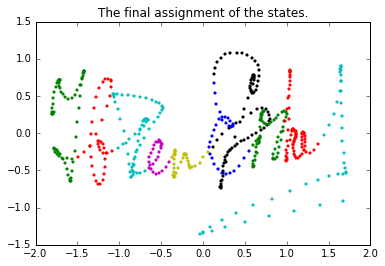

In [14]:
display(Image(filename='../resources/images/hmm1.png'))

/tmp/ipykernel_663007/2700183937.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


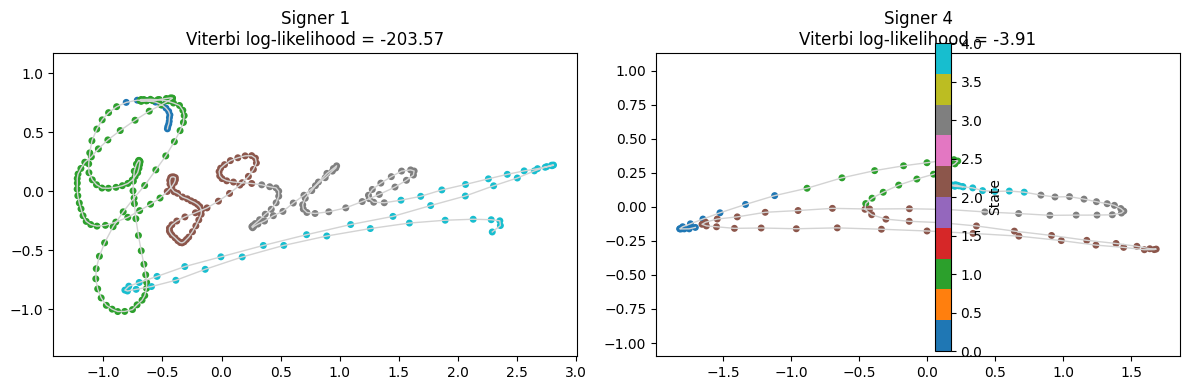

In [15]:
def plot_viterbi_states(ax, signal, model, title):
    seq, ll = model.viterbi(signal)
    ax.plot(signal[0, :], signal[1, :], color='lightgray', linewidth=1)
    scatter = ax.scatter(signal[0, :], signal[1, :], c=seq, cmap='tab10', s=16)
    ax.set_title(f'{title}\nViterbi log-likelihood = {ll:.2f}')
    ax.axis('equal')
    return scatter

sign1 = sign_norm(read_signatures('../resources/data/signatures/sign1/*.txt')[0][:2, :])
sign4 = sign_norm(read_signatures('../resources/data/signatures/sign4/*.txt')[1][:2, :])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
scatter = plot_viterbi_states(axes[0], sign1, sign_models[0], 'Signer 1')
scatter = plot_viterbi_states(axes[1], sign4, sign_models[3], 'Signer 4')
fig.colorbar(scatter, ax=axes, label='State')
plt.tight_layout()


# Signature classification


Assume that we have built probabilistic models of a number of signatories. If your client is a major bank, this can run into the millions. For signature verification, you are presented with a signature sequence as well as a claim about the identity of the signatory. The task of the system is to verify this claim. That means that the signature, i.e. the observation sequence, needs to be fitted to the claimed model. If it is a good fit, the signature is accepted. Otherwise it is rejected. It is not so straightforward to decide what is a good fit and we will not pursue that question here. Here our aim is just to quantify how well the signature corresponds to the model. The algorithm we use for this is **the forward algorithm which returns the likelihood of the observed sequence under the model**. Since a likelihood is returned (and not a probability), it is not so easy to decide what is an acceptable fit to accept the sequence, as alluded to above.  (Further, since the likelihood depends on the length of the sequence, it is common to normalize the (log-)likelihood with respect to the number of observations.)

We now turn to classifying signatures known to come from a specific group of individuals, or signature classification.  Note that signature verification is a broader problem, where one must detect whether a signature belongs to a specific individual - this poses complications we do not discuss further here.

For this section, we use the HMM models built earlier for our signatories, and use them to classify the 5 test signatures of each individual.  **Assuming each signatory is equally likely a priori, classify each signature using these models, and provide a confusion matrix and the test accuracy of the classifier**.

In theory, the likelihood of a signature is calculated with the forward algorithm, but it is also common to approximate this by the likelihood of the most likely sequence, as extracted from the Viterbi algorithm.  For this task, use the latter approach by default.  *However, you should be aware of this approximation.*

In [16]:
import math

def get_test_signals(signer_num, num_features=2, num_test = 12):
    sign = read_signatures('../resources/data/signatures/sign'+str(signer_num)+'/*.txt')
    n_signs = len(sign)-num_test
    data = sign_norm(sign[n_signs][:num_features, :])
    length = [sign[n_signs].shape[1]]
    for i in range(n_signs+1, len(sign)):
        signi = sign_norm(sign[i][:num_features, :])
        data = np.hstack((data,signi))
        length.append(sign[i].shape[1])
    return data, length

testsigs = []
groundTruth = []
predict = []

for signer in range(5):
    data, length = get_test_signals(signer+1)
    newSigs = np.hsplit(data, np.cumsum(length)[:-1])
    groundTruth += [(signer+1)] * len(newSigs)
    testsigs += newSigs

for signal in testsigs:
    scores = [model.viterbi(signal)[1] for model in sign_models]
    predict.append(int(np.argmax(scores)) + 1)

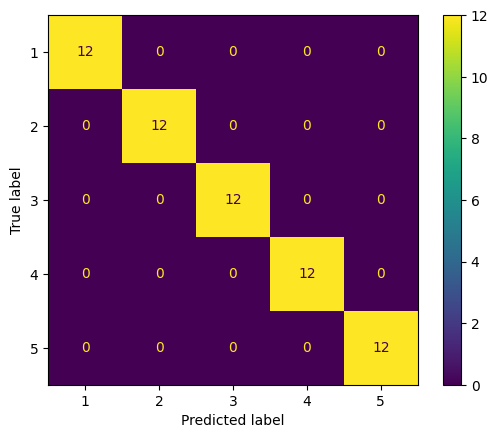

In [17]:
# After completing the code cell above, this should plot the confusion matrix.
ConfusionMatrixDisplay.from_predictions(groundTruth, predict)

In [18]:
accuracy = np.mean(np.array(groundTruth) == np.array(predict))
print(f'Test accuracy: {accuracy:.3f}')

Test accuracy: 1.000


# Helper Methods
---

## Markov Path Probability

Use this helper when a question gives you a Markov transition matrix and asks for the probability of one exact sequence of states. Because the full path is specified, you do **not** sum over alternatives; you just multiply the transition probabilities along the path.

In [19]:
def markov_path_probability(trans, states, start_state, future_states, show_steps=True):
    """
    Calculate the probability of one exact state path in a Markov chain.

    Parameters
    ----------
    trans : ndarray of shape (n_states, n_states)
        Transition matrix where rows are current states and columns are next states.
    states : list[str] | tuple[str]
        State labels in the same order as the matrix rows/columns.
    start_state : str
        Known starting state.
    future_states : list[str] | tuple[str]
        Exact sequence of later states.
    show_steps : bool
        If True, print each transition used in the product.

    Returns
    -------
    prob : float
        Probability of the exact path.
    """
    idx = {state: i for i, state in enumerate(states)}
    full_path = [start_state] + list(future_states)
    prob = 1.0
    steps = []

    for current_state, next_state in zip(full_path[:-1], full_path[1:]):
        step_prob = trans[idx[current_state], idx[next_state]]
        prob *= step_prob
        steps.append((current_state, next_state, step_prob))

    if show_steps:
        for current_state, next_state, step_prob in steps:
            print(f'P({next_state}|{current_state}) = {step_prob}')
        print(f'Exact path probability = {prob}')

    return prob


# Example:
weather_states = ['R', 'C', 'S']
weather_trans = np.array([
    [0.3, 0.1, 0.6],
    [0.5, 0.4, 0.1],
    [0.2, 0.3, 0.5]
])

weather_prob = markov_path_probability(
    weather_trans,
    weather_states,
    start_state='C',
    future_states=['S', 'R', 'C', 'S']
)
print('Answer:', weather_prob)


P(S|C) = 0.1
P(R|S) = 0.2
P(C|R) = 0.1
P(S|C) = 0.1
Exact path probability = 0.00020000000000000006
Answer: 0.00020000000000000006


## HMM vs GMM

- Both are **generative** probabilistic models.
- Both are commonly trained with **EM** to maximize likelihood.
- A **GMM does not model sequence order or time dependence**.
- An **HMM does model sequence dependence** through hidden-state transitions.
- Both are usually fit in an **unsupervised** way.
- Both can still be used for **classification** if you have labeled data and train one model per class.
- Fast exam check: shared truths are usually **EM** and **can be used for classification**.

**Example**

Which of the following statements about the relationship between GMMs and HMMs are true

- a. GMMs are generative models, while HMMs are discriminative models.
- b. HMMs and GMMs both implicitly model the length of observation sequences
- c. They both use the EM algorithm to maximize the likelihood function
- d. HMMs are a special case of GMMs
- e. GMMs and HMMs are both supervised models
- f. Both models can be used to build a classifier from a labeled data set

Correct answer: c, f.


## Valid HMM Topologies

Use this for short theory questions about whether a diagram can represent an HMM.

- A valid HMM is a **directed graph** of hidden states.
- It may have **self-loops**, **skip transitions**, and even **backward transitions**.
- So it does **not** have to be left-to-right to be valid.
- The `Start` state should have **no incoming** transitions.
- The `End` state should have **no outgoing** transitions.
- Each state's outgoing transition probabilities must be able to sum to **1**.

Fast exam check: self-loops and extra directed edges are fine; transitions **into Start** or **out of End** are red flags.

## MAP Classification From Priors And Log-Likelihoods

Use this when you are given one HMM per class, class priors, and `log p(x|M_i)` values from the forward algorithm. To find the most likely class **a posteriori**, compare:

- `log p(M_i|x) ∝ log p(x|M_i) + log p(M_i)`

You do not need the denominator `p(x)` for the argmax. Fast exam check: **add log-prior to log-likelihood, then choose the largest value**.


In [20]:
def map_class_from_priors_and_logliks(priors, logliks, class_labels=None, show_steps=True):
    """Return the MAP class from class priors and class-conditional log-likelihoods."""
    priors = np.asarray(priors, dtype=float)
    logliks = np.asarray(logliks, dtype=float)

    if class_labels is None:
        class_labels = [f'M{i+1}' for i in range(len(priors))]

    logpriors = np.log(priors)
    logpost_unnorm = logpriors + logliks
    best_idx = int(np.argmax(logpost_unnorm))

    if show_steps:
        for label, prior, loglik, score in zip(class_labels, priors, logliks, logpost_unnorm):
            print(f'{label}: prior={prior:.4f}, loglik={loglik:.4f}, log-prior+loglik={score:.4f}')
        print(f'\nMAP class: {class_labels[best_idx]}')

    return class_labels[best_idx], best_idx, logpost_unnorm


# Example
priors = [0.07, 0.13, 0.31, 0.27, 0.22]
logliks = [-1.31, -1.89, -2.04, -1.47, -1.51]
map_label, map_idx, scores = map_class_from_priors_and_logliks(priors, logliks)
print('Class index:', map_idx + 1)


M1: prior=0.0700, loglik=-1.3100, log-prior+loglik=-3.9693
M2: prior=0.1300, loglik=-1.8900, log-prior+loglik=-3.9302
M3: prior=0.3100, loglik=-2.0400, log-prior+loglik=-3.2112
M4: prior=0.2700, loglik=-1.4700, log-prior+loglik=-2.7793
M5: prior=0.2200, loglik=-1.5100, log-prior+loglik=-3.0241

MAP class: M4
Class index: 4


## Diagonal Covariance Estimation

Use this for theory questions about `diagcov=True`.

- Computing the full covariance matrix and then discarding off-diagonal entries gives the **same diagonal values** as computing each dimension's variance directly.
- So the final diagonal covariance matrix is the **same** either way.
- Directly computing only the variances is **more efficient**, because you avoid unnecessary off-diagonal covariance calculations.
- Fast exam check: **same result, less computation**.

Correct MCQ pattern: `same results; direct variance approach is more efficient`.


## Recognising HMM Code

Use this for theory questions that show a code snippet and ask which HMM method it belongs to.

- `argmax` over previous states or backpointers means **_viterbi**.
- `sum` in probability space, or `logaddexp` in log space, over previous states means **_forward**.
- No search over states, just add transition and emission terms for one given sequence, means **_score**.
- Re-running Viterbi on every training signal and rebuilding state allocations/transitions means **_calcstates**.
- Computing means/covariances from observations assigned to each state means **_updatecovs**.
- Alternating state re-allocation and parameter re-estimation until convergence means **_em**.
- Sampling next states from transition probabilities and observations from Gaussians means **sample**.


## Counting Possible State Sequences

Use this when a question asks how many hidden-state sequences are possible for a signal of a given length.

- For a **fully connected** HMM with `N` emitting states and signal length `T`, the count is `N^T`.
- Reason: each time step can be any of the `N` states.
- For other topologies, count legal paths through the transition graph.
- Fast exam check: fully connected gives `N^T`.


In [ ]:
def count_state_sequences(trans, length, require_end=True):
    """Count legal emitting-state sequences of a given length for an HMM transition matrix."""
    trans = np.asarray(trans)
    n_states = trans.shape[0] - 1
    if length <= 0:
        return 0

    start_ok = (trans[-1, :n_states] > 0).astype(np.int64)
    adj = (trans[:n_states, :n_states] > 0).astype(np.int64)
    end_ok = (trans[:n_states, -1] > 0)

    counts = start_ok.copy()
    for _ in range(1, length):
        counts = counts @ adj

    if require_end:
        return int(counts[end_ok].sum())
    return int(counts.sum())


def count_fully_connected_sequences(n_states, length):
    """Count sequences for a fully connected HMM."""
    return int(n_states ** length)


# Example: 4 emitting states, length 5, fully connected
print(count_fully_connected_sequences(4, 5))

# Example: use the actual left-to-right topology from this assignment
ltr_trans = HMM._ltrtrans(4)
print(count_state_sequences(ltr_trans, 5))


## Fit And Summarise A Toy HMM

Use this when a question gives you a few small signals, asks you to fit an HMM, and then asks which transition matrix / means / variances match the trained model.

"You fit a left-to-right HMM with 3 emitting states to the
two signals below using your assignment implementation. Thereafter you analyse a number of signals with the
fitted HMM."
"You print out the transition matrix, and the variances and means of the Gaussian distributions associated with
each emitting state. Which of the following most closely matches your output?"

- Fit the HMM on the provided signals.
- Print the transition matrix.
- Print the per-state variances and means.
- Fast exam check: for a left-to-right HMM, the learned states usually appear in temporal order, so the means should make sense from early to late parts of the signal.
- Remember: the last row of the transition matrix is the initial non-emitting state's transitions.


In [30]:
def fit_and_summarise_hmm(signals, n_states, diagcov=True, show=True):
    """Fit an HMM to a list of signals and return the model, transition matrix, variances, and means."""
    data = np.hstack(signals)
    lengths = [signal.shape[1] for signal in signals]
    hmm = HMM(diagcov=diagcov)
    hmm.fit(data, lengths, n_states)

    trans = hmm.trans
    variances = np.array([float(np.squeeze(d.get_cov())) for d in hmm.dists])
    means = np.array([float(np.squeeze(d.get_mean())) for d in hmm.dists])

    if show:
        print(f"{trans}\n")
        print(f"{variances}\n")
        print(f"{means}\n")

    return hmm, trans, variances, means


# Example
signal1 = np.array([[ 1.2, 1.1, 0.9, 1.0, 0.8, 0.2, 0.1, 0.3, 3.4, 3.6, 3.5]])
signal2 = np.array([[0.8, 1.2, 0.4, 0.2, 0.15, 2.8, 3.6]])
fit_and_summarise_hmm([signal1, signal2], n_states=3)


[[0.71428571 0.28571429 0.         0.        ]
 [0.         0.66666667 0.33333333 0.        ]
 [0.         0.         0.6        0.4       ]
 [1.         0.         0.         0.        ]]

[0.02571429 0.00979167 0.0896    ]

[1.    0.225 3.38 ]



(<hmm_class.HMM at 0x753428615280>,
 array([[0.71428571, 0.28571429, 0.        , 0.        ],
        [0.        , 0.66666667, 0.33333333, 0.        ],
        [0.        , 0.        , 0.6       , 0.4       ],
        [1.        , 0.        , 0.        , 0.        ]]),
 array([0.02571429, 0.00979167, 0.0896    ]),
 array([1.   , 0.225, 3.38 ]))

## Fit And Decode A Signal With Viterbi

Use this when a question gives you training signals, tells you to fit a toy HMM, and then asks for the most likely hidden-state sequence of a new signal.

"What is the most likely emitting state sequence for the signal below using the fitted model?"

- Fit the HMM on the training signals.
- Run `viterbi` on the new signal.
- Read off the state sequence.
- Fast exam check: the returned sequence is the most likely path, not the marginal likelihood answer.


In [27]:
def fit_and_decode_viterbi(train_signals, test_signal, n_states, diagcov=True, show=True):
    """Fit an HMM on training signals and decode a test signal with Viterbi."""
    hmm, trans, variances, means = fit_and_summarise_hmm(
        train_signals,
        n_states=n_states,
        diagcov=diagcov,
        show=False,
    )
    seq, ll = hmm.viterbi(test_signal)

    if show:
        print('Transition matrix:')
        print(trans)
        print('Variances:', variances)
        print('Means:', means)
        print('Viterbi sequence:', seq)
        print('Viterbi log-likelihood:', ll)

    return hmm, seq, ll


# Example
signal1 = np.array([[ 1.2, 1.1, 0.9, 1.0, 0.8, 0.2, 0.1, 0.3, 3.4, 3.6, 3.5]])
signal2 = np.array([[0.8, 1.2, 0.4, 0.2, 0.15, 2.8, 3.6]])
signal = np.array([[0.9515792, 0.9832767, 1.04633007, 0.6464327, 0.56207072, 0.4116689,
                    0.31622856, 0.20819263, 3.57707616]])
fit_and_decode_viterbi([signal1, signal2], signal, n_states=3)


Transition matrix:
[[0.71428571 0.28571429 0.         0.        ]
 [0.         0.66666667 0.33333333 0.        ]
 [0.         0.         0.6        0.4       ]
 [1.         0.         0.         0.        ]]
Variances: [0.02571429 0.00979167 0.0896    ]
Means: [1.    0.225 3.38 ]
Viterbi sequence: [0 0 0 0 0 1 1 1 2]
Viterbi log-likelihood: -5.085711614055926


(<hmm_class.HMM at 0x753429790e30>,
 array([0, 0, 0, 0, 0, 1, 1, 1, 2]),
 -5.085711614055926)

## Fit And Score A Fixed State Sequence

Use this when a question gives you training signals, tells you to fit a toy HMM, and then asks for the log-likelihood of one specific hidden-state sequence for a new signal.

"Which integer is closest to the log-likelihood of the emitting state sequence [0,0,0,0,1,1,1,1,2] for the signal below
using the fitted model?"

- Fit the HMM on the training signals.
- Use `score` with the given signal and the given state sequence.
- This is different from Viterbi: here the state sequence is already fixed.
- Fast exam check: fixed path means **score**, not **forward** and not **viterbi**.


In [28]:
def fit_and_score_sequence(train_signals, test_signal, seq, n_states, diagcov=True, show=True):
    """Fit an HMM on training signals and score one fixed state sequence."""
    hmm, trans, variances, means = fit_and_summarise_hmm(
        train_signals,
        n_states=n_states,
        diagcov=diagcov,
        show=False,
    )
    ll = hmm.score(test_signal, seq)

    if show:
        print('Transition matrix:')
        print(trans)
        print('Variances:', variances)
        print('Means:', means)
        print('Sequence:', seq)
        print('Score:', ll)
        print('Closest integer:', round(ll))

    return hmm, ll


# Example
signal1 = np.array([[ 1.2, 1.1, 0.9, 1.0, 0.8, 0.2, 0.1, 0.3, 3.4, 3.6, 3.5]])
signal2 = np.array([[0.8, 1.2, 0.4, 0.2, 0.15, 2.8, 3.6]])
signal = np.array([[0.9515792, 0.9832767, 1.04633007, 0.6464327, 0.56207072, 0.4116689,
                    0.31622856, 0.20819263, 3.57707616]])
seq = [0, 0, 0, 0, 1, 1, 1, 1, 2]
fit_and_score_sequence([signal1, signal2], signal, seq, n_states=3)


Transition matrix:
[[0.71428571 0.28571429 0.         0.        ]
 [0.         0.66666667 0.33333333 0.        ]
 [0.         0.         0.6        0.4       ]
 [1.         0.         0.         0.        ]]
Variances: [0.02571429 0.00979167 0.0896    ]
Means: [1.    0.225 3.38 ]
Sequence: [0, 0, 0, 0, 1, 1, 1, 1, 2]
Score: -6.744553788846548
Closest integer: -7


(<hmm_class.HMM at 0x75342864e4e0>, -6.744553788846548)

## Fit And Score A Signal With Forward

Use this when a question gives you training signals, tells you to fit a toy HMM, and then asks for the log-likelihood of a new signal under the fitted model.

"Which integer is closest to the log-likelihood of the signal below using the fitted model?"

- Fit the HMM on the training signals.
- Use `forward` on the new signal.
- This sums over all legal hidden-state sequences.
- Fast exam check: observation likelihood under the model means **forward**.


In [29]:
def fit_and_forward_score(train_signals, test_signal, n_states, diagcov=True, show=True):
    """Fit an HMM on training signals and compute the forward log-likelihood of a test signal."""
    hmm, trans, variances, means = fit_and_summarise_hmm(
        train_signals,
        n_states=n_states,
        diagcov=diagcov,
        show=False,
    )
    ll = hmm.forward(test_signal)

    if show:
        print('Transition matrix:')
        print(trans)
        print('Variances:', variances)
        print('Means:', means)
        print('Forward log-likelihood:', ll)
        print('Closest integer:', round(ll))

    return hmm, ll


# Example
signal1 = np.array([[ 1.2, 1.1, 0.9, 1.0, 0.8, 0.2, 0.1, 0.3, 3.4, 3.6, 3.5]])
signal2 = np.array([[0.8, 1.2, 0.4, 0.2, 0.15, 2.8, 3.6]])
signal = np.array([[0.9515792, 0.9832767, 1.04633007, 0.6464327, 0.56207072, 0.4116689,
                    0.31622856, 0.20819263, 3.57707616]])
fit_and_forward_score([signal1, signal2], signal, n_states=3)


Transition matrix:
[[0.71428571 0.28571429 0.         0.        ]
 [0.         0.66666667 0.33333333 0.        ]
 [0.         0.         0.6        0.4       ]
 [1.         0.         0.         0.        ]]
Variances: [0.02571429 0.00979167 0.0896    ]
Means: [1.    0.225 3.38 ]
Forward log-likelihood: -4.907218161825327
Closest integer: -5


(<hmm_class.HMM at 0x753428628e30>, -4.907218161825327)

# Other Utils:

## Quick Exam Facts

- `score(signal, seq)` computes `log p(signal, seq)` for one fixed state sequence.
- `viterbi(signal)` returns the **best** state sequence and its log-likelihood.
- `forward(signal)` computes `log p(signal)` by summing over **all** legal state sequences.
- Therefore: `forward log-likelihood >= viterbi log-likelihood`.
- For short signals: `forward(signal) = logsumexp(score(signal, seq) over all legal seq)`.
- For fully connected HMMs with `N` states and length `T`: number of state sequences is `N^T`.
- For MAP classification: choose the largest `log p(x|M_i) + log p(M_i)`.
- `argmax` over previous states suggests **Viterbi**; `logaddexp` suggests **forward**.


## Exhaustive Short-Signal Analysis

Use this for small toy questions where you want to inspect everything at once: emission log-likelihoods, all legal state sequences, each sequence score, the Viterbi answer, and the forward log-likelihood. This is especially useful when the signal is short enough that enumerating all legal paths is practical.


In [31]:
def emission_loglik_table(signal, dists):
    """Return a table of log p(x_t | state_j). Rows are states, columns are time steps."""
    return np.array([[dist.logf(signal[:, t]) for t in range(signal.shape[1])] for dist in dists])


def enumerate_legal_state_sequences(trans, length, require_end=True):
    """Enumerate all legal emitting-state sequences for a given HMM transition matrix and signal length."""
    trans = np.asarray(trans)
    n_states = trans.shape[0] - 1
    sequences = []

    def extend(prefix):
        if len(prefix) == length:
            if (not require_end) or (trans[prefix[-1], -1] > 0):
                sequences.append(prefix.copy())
            return
        current = prefix[-1]
        for nxt in np.where(trans[current, :n_states] > 0)[0]:
            extend(prefix + [int(nxt)])

    for start in np.where(trans[-1, :n_states] > 0)[0]:
        extend([int(start)])

    return sequences


def exhaustive_hmm_analysis(hmm, signal, require_end=True, sort_desc=True):
    """Analyse a short signal by enumerating all legal state sequences under an HMM."""
    seqs = enumerate_legal_state_sequences(hmm.trans, signal.shape[1], require_end=require_end)
    scored = [(seq, hmm.score(signal, seq)) for seq in seqs]
    scored = sorted(scored, key=lambda x: x[1], reverse=sort_desc)
    vit_seq, vit_ll = hmm.viterbi(signal)
    fwd_ll = hmm.forward(signal)
    emit_lls = emission_loglik_table(signal, hmm.dists)

    print('Emission log-likelihood table (rows=states, cols=time):')
    print(emit_lls)
    print('\nLegal state sequences and scores:')
    for seq, ll in scored:
        print(seq, ll)
    print('\nViterbi sequence:', vit_seq)
    print('Viterbi log-likelihood:', vit_ll)
    print('Forward log-likelihood:', fwd_ll)
    print('Difference forward - viterbi:', fwd_ll - vit_ll)

    return {
        'emission_logliks': emit_lls,
        'scores': scored,
        'viterbi_sequence': vit_seq,
        'viterbi_loglik': vit_ll,
        'forward_loglik': fwd_ll,
    }


# Example for short toy-signal analysis
toy_means = [1.0, 0.19285714, 3.38]
toy_covs = [0.01666667, 0.01459184, 0.0896]
toy_trans = np.array([
    [0.66666667, 0.33333333, 0.0, 0.0],
    [0.0, 0.71428571, 0.28571429, 0.0],
    [0.0, 0.0, 0.6, 0.4],
    [1.0, 0.0, 0.0, 0.0]
])
toy_dists = [Gaussian(np.array([m]), np.array([[c]])) for m, c in zip(toy_means, toy_covs)]
toy_hmm = HMM()
toy_hmm.load(toy_trans, toy_dists)
short_signal = np.array([[1.0, 0.6, 0.5, 3.57707616]])
exhaustive_hmm_analysis(toy_hmm, short_signal)


Emission log-likelihood table (rows=states, cols=time):
[[ 1.12823365e+00 -3.67176539e+00 -6.37176485e+00 -1.98111373e+02]
 [-2.11287139e+01 -4.48536087e+00 -2.03780895e+00 -3.91248547e+02]
 [-3.13221136e+01 -4.28399707e+01 -4.59984528e+01  7.05258836e-02]]

Legal state sequences and scores:
[0, 0, 1, 2] -8.183945894952732
[0, 1, 1, 2] -8.928548508991248
[0, 1, 2, 2] -53.063545782364024

Viterbi sequence: [0 0 1 2]
Viterbi log-likelihood: -8.183945894952734
Forward log-likelihood: -7.795340116574732
Difference forward - viterbi: 0.38860577837800214


{'emission_logliks': array([[ 1.12823365e+00, -3.67176539e+00, -6.37176485e+00,
         -1.98111373e+02],
        [-2.11287139e+01, -4.48536087e+00, -2.03780895e+00,
         -3.91248547e+02],
        [-3.13221136e+01, -4.28399707e+01, -4.59984528e+01,
          7.05258836e-02]]),
 'scores': [([0, 0, 1, 2], -8.183945894952732),
  ([0, 1, 1, 2], -8.928548508991248),
  ([0, 1, 2, 2], -53.063545782364024)],
 'viterbi_sequence': array([0, 0, 1, 2]),
 'viterbi_loglik': -8.183945894952734,
 'forward_loglik': -7.795340116574732}